In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../..").resolve()))

import pandas as pd
import numpy as np
from world_cup_2026.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, RANDOM_SEED

np.random.seed(RANDOM_SEED)

# Load feature matrix
df_master = pd.read_parquet(PROCESSED_DATA_DIR / "master_features.parquet")

# Load WC2026 teams
df_teams = pd.read_csv(RAW_DATA_DIR / "areezvisram12_fixture" / "teams.csv")

print(f"Feature matrix: {df_master.shape}")
print(f"WC2026 teams: {len(df_teams)}")
print(f"Date range in matrix: {df_master['date'].min().date()} → {df_master['date'].max().date()}")
print("Setup complete.")

Feature matrix: (9796, 89)
WC2026 teams: 48
Date range in matrix: 2016-01-03 → 2026-03-31
Setup complete.


In [2]:
from world_cup_2026.data_ingestion.normalize import normalize_team_name
from world_cup_2026.features.elo import calculate_elo
from world_cup_2026.features.form import FormCalculator
from world_cup_2026.data_ingestion.normalize import normalize_dataframe_teams

AS_OF = pd.Timestamp("2026-03-31")

# Normalize team names in fixture
df_teams["team_norm"] = df_teams["team_name"].map(normalize_team_name)

# Load full results for Elo and Form snapshot
df_results = pd.read_csv(
    RAW_DATA_DIR / "martj42_results" / "results.csv",
    parse_dates=["date"]
)
df_results_norm = normalize_dataframe_teams(df_results, ["home_team", "away_team"])
df_elo = calculate_elo(df_results_norm)
calc = FormCalculator(df_results_norm, windows=[5, 10, 20])

print("Building team snapshots...")
snapshots = []

for _, team_row in df_teams.iterrows():
    team = team_row["team_norm"]
    group = team_row["group_letter"]

    # --- Elo snapshot ---
    mask = (
        ((df_elo["home_team"] == team) | (df_elo["away_team"] == team))
        & (df_elo["date"] < AS_OF)
    )
    team_matches = df_elo[mask].sort_values("date")

    if team_matches.empty:
        elo = 1500.0
    else:
        last = team_matches.iloc[-1]
        elo = last["elo_pre_home"] if last["home_team"] == team else last["elo_pre_away"]

    # --- Form snapshot ---
    form_10 = calc.get_team_current_form(team, as_of=AS_OF, window=10)
    form_5  = calc.get_team_current_form(team, as_of=AS_OF, window=5)
    form_20 = calc.get_team_current_form(team, as_of=AS_OF, window=20)

    snapshot = {
        "team": team,
        "group": group,
        "elo": round(elo, 1),
    }
    snapshot.update(form_5)
    snapshot.update(form_10)
    snapshot.update(form_20)
    snapshots.append(snapshot)

df_snapshot = pd.DataFrame(snapshots)
print(f"Snapshot shape: {df_snapshot.shape}")
print(f"\nTop 10 by Elo:")
print(df_snapshot[["team", "group", "elo"]].sort_values("elo", ascending=False).head(10).to_string(index=False))

2026-04-03 16:39:12.020 | WARNING  | world_cup_2026.data_ingestion.normalize:normalize_team_name:193 - Unknown team name: 'Guernsey' — add to normalize.py if needed.
2026-04-03 16:39:12.020 | WARNING  | world_cup_2026.data_ingestion.normalize:normalize_team_name:193 - Unknown team name: 'Jersey' — add to normalize.py if needed.
2026-04-03 16:39:12.020 | WARNING  | world_cup_2026.data_ingestion.normalize:normalize_team_name:193 - Unknown team name: 'Alderney' — add to normalize.py if needed.
2026-04-03 16:39:12.030 | WARNING  | world_cup_2026.data_ingestion.normalize:normalize_team_name:193 - Unknown team name: 'Catalonia' — add to normalize.py if needed.
2026-04-03 16:39:12.032 | WARNING  | world_cup_2026.data_ingestion.normalize:normalize_team_name:193 - Unknown team name: 'Basque Country' — add to normalize.py if needed.
2026-04-03 16:39:12.034 | WARNING  | world_cup_2026.data_ingestion.normalize:normalize_team_name:193 - Unknown team name: 'Brittany' — add to normalize.py if needed.

Building team snapshots...
Snapshot shape: (48, 36)

Top 10 by Elo:
       team group    elo
      Spain     H 2195.2
  Argentina     J 2153.1
     France     I 2113.7
    England     L 2089.6
   Colombia     K 2032.1
Netherlands     F 2021.2
     Brazil     C 2015.6
    Germany     E 2014.9
   Portugal     K 2000.3
    Morocco     C 1989.9


In [3]:
from sklearn.preprocessing import StandardScaler

# Select numeric features for clustering
# We use Elo + form_10 (most balanced window) as core features
# Exclude form_5 and form_20 to avoid redundancy — they're correlated
CLUSTER_FEATURES = [
    "elo",
    "form_10_win_rate",
    "form_10_draw_rate",
    "form_10_loss_rate",
    "form_10_goals_scored_avg",
    "form_10_goals_conceded_avg",
    "form_10_goal_diff_avg",
    "form_10_clean_sheet_rate",
    "form_10_failed_score_rate",
    "form_10_points_avg",
    "form_10_weighted_points",
]

# Verify all columns exist
missing = [c for c in CLUSTER_FEATURES if c not in df_snapshot.columns]
if missing:
    print(f"Missing columns: {missing}")
else:
    print("All feature columns found.")

X = df_snapshot[CLUSTER_FEATURES].values
teams = df_snapshot["team"].values
groups = df_snapshot["group"].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix for clustering: {X_scaled.shape}")
print(f"Features: {CLUSTER_FEATURES}")

All feature columns found.
Feature matrix for clustering: (48, 11)
Features: ['elo', 'form_10_win_rate', 'form_10_draw_rate', 'form_10_loss_rate', 'form_10_goals_scored_avg', 'form_10_goals_conceded_avg', 'form_10_goal_diff_avg', 'form_10_clean_sheet_rate', 'form_10_failed_score_rate', 'form_10_points_avg', 'form_10_weighted_points']


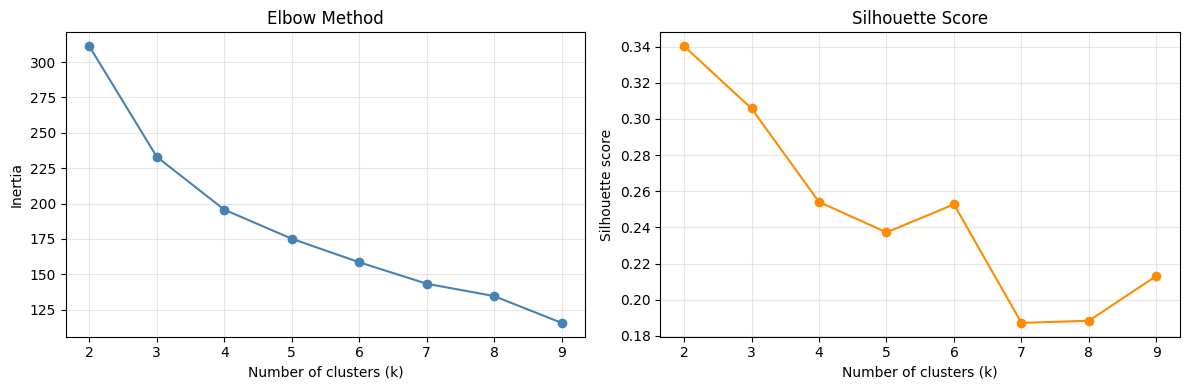


Silhouette scores:
  k=2: 0.3402
  k=3: 0.3058
  k=4: 0.2541
  k=5: 0.2372
  k=6: 0.2527
  k=7: 0.1872
  k=8: 0.1884
  k=9: 0.2131

Best k by silhouette: 2


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
K_RANGE = range(2, 10)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_RANGE), inertias, marker="o", color="steelblue")
ax1.set_title("Elbow Method")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), silhouettes, marker="o", color="darkorange")
ax2.set_title("Silhouette Score")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../outputs/figures/clustering_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K_RANGE, silhouettes):
    print(f"  k={k}: {s:.4f}")

best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f"\nBest k by silhouette: {best_k}")

## 5. KMeans Clustering (k=4)

Fit KMeans with the selected k=4 on the 11 standardized features.
Visualize cluster separation using PCA (2 components) as a 2D projection.

> Note: PCA here is used **only for visualization**. A full PCA analysis
> (explained variance, biplot, loadings) is covered in Section 7.

KMeans fitted.
Inertia: 195.22

Cluster sizes:
cluster
0    12
1    16
2    14
3     6

PCA variance explained — PC1: 58.9%, PC2: 20.2%
Total: 79.1%

Figure saved → C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\outputs\figures\clustering_pca_2d.png


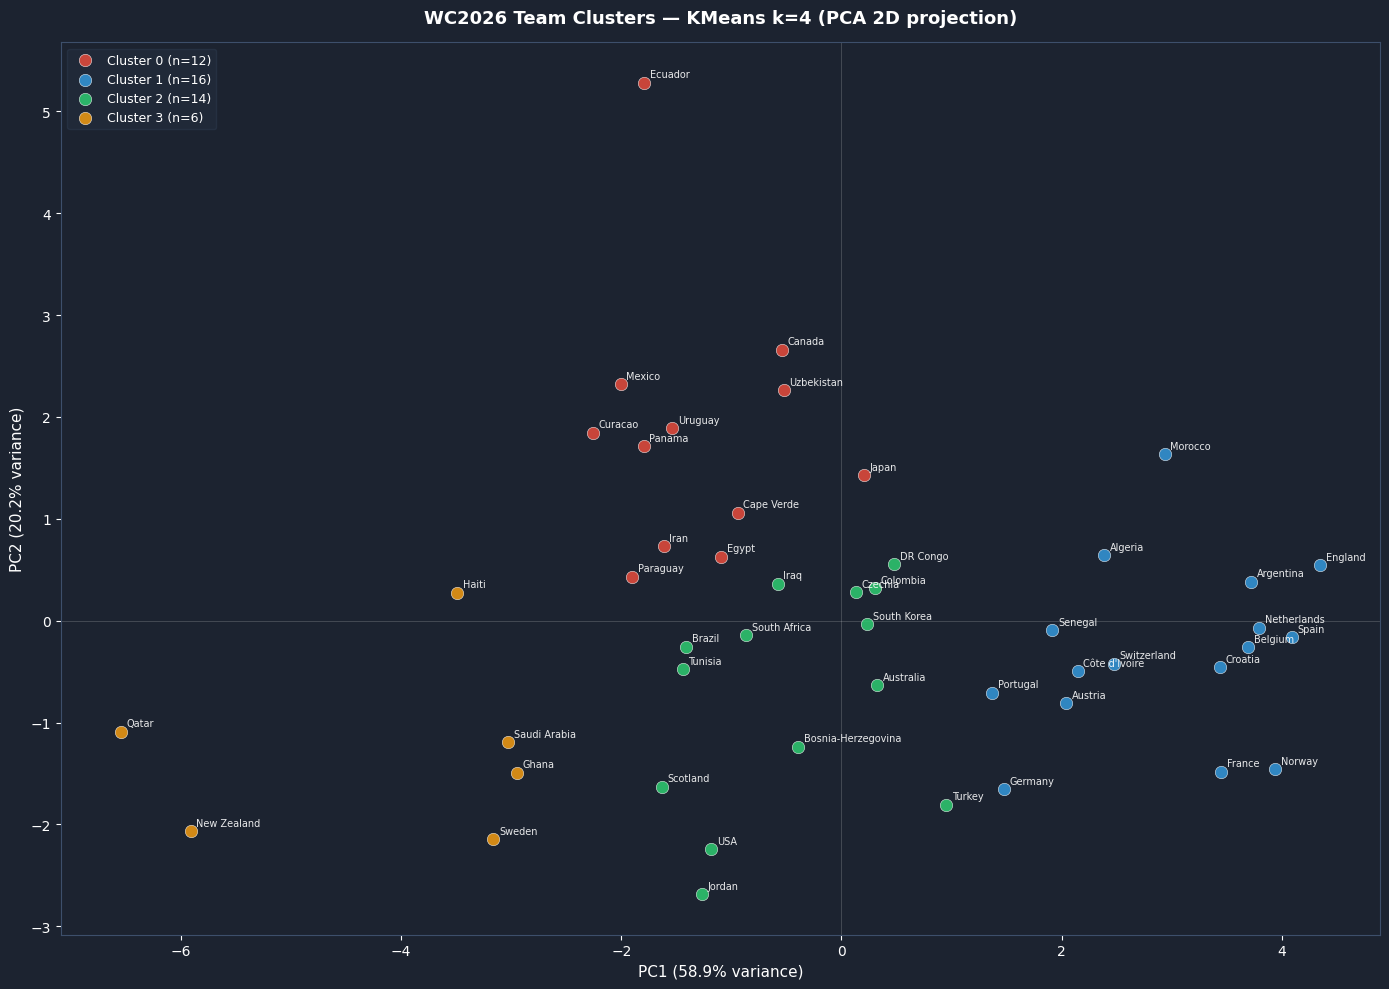

In [8]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 1. Fit KMeans ─────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, n_init=50, random_state=RANDOM_SEED)
cluster_labels = kmeans.fit_predict(X_scaled)

df_snapshot["cluster"] = cluster_labels

print("KMeans fitted.")
print(f"Inertia: {kmeans.inertia_:.2f}")
print("\nCluster sizes:")
print(df_snapshot["cluster"].value_counts().sort_index().to_string())

# ── 2. PCA 2D projection ───────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

df_snapshot["pc1"] = X_pca[:, 0]
df_snapshot["pc2"] = X_pca[:, 1]

var_explained = pca.explained_variance_ratio_
print(f"\nPCA variance explained — PC1: {var_explained[0]:.1%}, PC2: {var_explained[1]:.1%}")
print(f"Total: {sum(var_explained):.1%}")

# ── 3. Plot ────────────────────────────────────────────────────────────────────
CLUSTER_COLORS = {0: "#E74C3C", 1: "#3498DB", 2: "#2ECC71", 3: "#F39C12"}
CLUSTER_LABELS = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3",
}

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("#1C2330")
ax.set_facecolor("#1C2330")

for cluster_id, color in CLUSTER_COLORS.items():
    mask = df_snapshot["cluster"] == cluster_id
    subset = df_snapshot[mask]
    ax.scatter(
        subset["pc1"],
        subset["pc2"],
        c=color,
        s=80,
        alpha=0.85,
        edgecolors="white",
        linewidths=0.4,
        label=f"Cluster {cluster_id} (n={mask.sum()})",
        zorder=3,
    )
    # Annotate team names
    for _, row in subset.iterrows():
        ax.annotate(
            row["team"],
            xy=(row["pc1"], row["pc2"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7,
            color="white",
            alpha=0.9,
        )

# Reference lines at origin
ax.axhline(0, color="white", linewidth=0.4, alpha=0.3)
ax.axvline(0, color="white", linewidth=0.4, alpha=0.3)

ax.set_xlabel(
    f"PC1 ({var_explained[0]:.1%} variance)",
    color="white", fontsize=11
)
ax.set_ylabel(
    f"PC2 ({var_explained[1]:.1%} variance)",
    color="white", fontsize=11
)
ax.set_title(
    "WC2026 Team Clusters — KMeans k=4 (PCA 2D projection)",
    color="white", fontsize=13, fontweight="bold", pad=14
)
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#3D4F6B")

legend = ax.legend(
    loc="upper left",
    framealpha=0.25,
    labelcolor="white",
    facecolor="#2C3E50",
    edgecolor="#3D4F6B",
    fontsize=9,
)

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig_path = FIGURES_DIR / "clustering_pca_2d.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"\nFigure saved → {fig_path}")
plt.show()

In [11]:
print("=" * 60)
print("CLUSTER PROFILES (sorted by avg Elo)")
print("=" * 60)

summary = (
    df_snapshot
    .groupby("cluster")
    .agg(
        n_teams=("team", "count"),
        avg_elo=("elo", "mean"),
        avg_form_wr=("form_10_win_rate", "mean"),
        avg_goals_scored=("form_10_goals_scored_avg", "mean"),
        avg_goals_conceded=("form_10_goals_conceded_avg", "mean"),
    )
    .sort_values("avg_elo", ascending=False)
    .round(2)
)
print(summary.to_string())

print()
for cid in summary.index:
    teams_in = (
        df_snapshot[df_snapshot["cluster"] == cid]
        .sort_values("elo", ascending=False)["team"]
        .tolist()
    )
    print(f"Cluster {cid} (n={len(teams_in)}): {', '.join(teams_in)}")
    print()

CLUSTER PROFILES (sorted by avg Elo)
         n_teams  avg_elo  avg_form_wr  avg_goals_scored  avg_goals_conceded
cluster                                                                     
1             16  1982.78         0.72              2.72                0.78
0             12  1846.70         0.38              1.28                0.78
2             14  1827.90         0.54              1.75                1.12
3              6  1678.82         0.32              1.22                1.47

Cluster 1 (n=16): Spain, Argentina, France, England, Netherlands, Germany, Portugal, Morocco, Croatia, Norway, Switzerland, Belgium, Senegal, Austria, Algeria, Côte d'Ivoire

Cluster 0 (n=12): Ecuador, Japan, Uruguay, Mexico, Canada, Iran, Paraguay, Uzbekistan, Panama, Egypt, Cape Verde, Curacao

Cluster 2 (n=14): Colombia, Brazil, Turkey, South Korea, USA, Australia, Scotland, Jordan, Czechia, Tunisia, Iraq, DR Congo, South Africa, Bosnia-Herzegovina

Cluster 3 (n=6): Saudi Arabia, Sweden, New 

Snapshot saved → C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\data\processed\team_snapshot_clustered.parquet
Shape: (48, 40)

Cluster distribution:
cluster_name
Elite                    16
Dynamic Mid-Tier         14
Consolidated Mid-Tier    12
Underdogs                 6
Figure saved → C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\outputs\figures\clustering_pca_2d_named.png


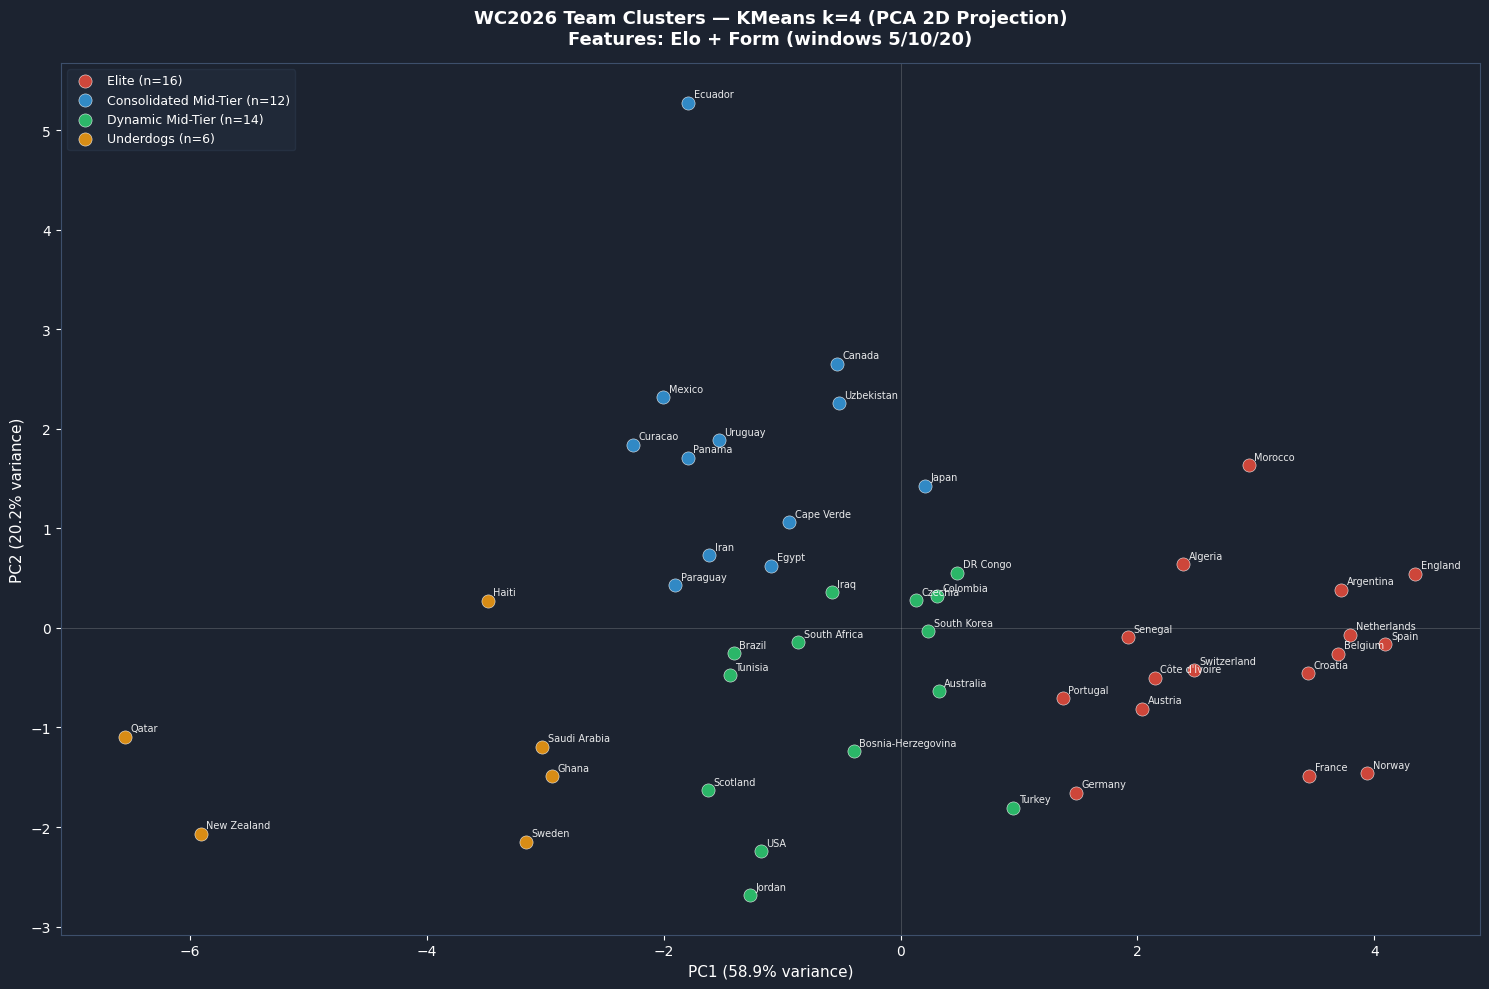

In [12]:
# ── Assign interpretive cluster names ─────────────────────────────────────────
CLUSTER_NAMES = {
    1: "Elite",
    0: "Consolidated Mid-Tier",
    2: "Dynamic Mid-Tier",
    3: "Underdogs",
}

df_snapshot["cluster_name"] = df_snapshot["cluster"].map(CLUSTER_NAMES)

# ── Save enriched snapshot ─────────────────────────────────────────────────────
from world_cup_2026.config import PROCESSED_DATA_DIR

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
snapshot_path = PROCESSED_DATA_DIR / "team_snapshot_clustered.parquet"
df_snapshot.to_parquet(snapshot_path, index=False)
print(f"Snapshot saved → {snapshot_path}")
print(f"Shape: {df_snapshot.shape}")
print(f"\nCluster distribution:")
print(df_snapshot["cluster_name"].value_counts().to_string())

# ── Final PCA plot with interpretive labels ────────────────────────────────────
CLUSTER_COLORS_NAMED = {
    "Elite":                 "#E74C3C",
    "Consolidated Mid-Tier": "#3498DB",
    "Dynamic Mid-Tier":      "#2ECC71",
    "Underdogs":             "#F39C12",
}

fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor("#1C2330")
ax.set_facecolor("#1C2330")

for name, color in CLUSTER_COLORS_NAMED.items():
    mask = df_snapshot["cluster_name"] == name
    subset = df_snapshot[mask]
    ax.scatter(
        subset["pc1"], subset["pc2"],
        c=color, s=90, alpha=0.88,
        edgecolors="white", linewidths=0.4,
        label=f"{name} (n={mask.sum()})",
        zorder=3,
    )
    for _, row in subset.iterrows():
        ax.annotate(
            row["team"],
            xy=(row["pc1"], row["pc2"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7, color="white", alpha=0.9,
        )

ax.axhline(0, color="white", linewidth=0.4, alpha=0.3)
ax.axvline(0, color="white", linewidth=0.4, alpha=0.3)

var_explained = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} variance)", color="white", fontsize=11)
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} variance)", color="white", fontsize=11)
ax.set_title(
    "WC2026 Team Clusters — KMeans k=4 (PCA 2D Projection)\n"
    "Features: Elo + Form (windows 5/10/20)",
    color="white", fontsize=13, fontweight="bold", pad=14,
)
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#3D4F6B")

ax.legend(
    loc="upper left", framealpha=0.25,
    labelcolor="white", facecolor="#2C3E50",
    edgecolor="#3D4F6B", fontsize=9,
)

plt.tight_layout()
fig_path = FIGURES_DIR / "clustering_pca_2d_named.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Figure saved → {fig_path}")
plt.show()

## 6. Cluster Interpretation

| Cluster | Name | n | Avg Elo | Form WR (10) | Avg Goals Scored |
|---|---|---|---|---|---|
| 1 | Elite | 16 | 1982 | 0.72 | 2.72 |
| 0 | Consolidated Mid-Tier | 12 | 1847 | 0.38 | 1.28 |
| 2 | Dynamic Mid-Tier | 14 | 1828 | 0.54 | 1.75 |
| 3 | Underdogs | 6 | 1679 | 0.32 | 1.22 |

### Elite (n=16)
The largest cluster by count, but the clearest by profile: highest Elo (avg 1983),
dominant recent form (72% win rate), and by far the best attacking output (2.72 goals/match).
Includes all traditional powerhouses — Spain, Argentina, France, England, Germany, Portugal,
Netherlands — plus Morocco and Senegal, who earned their place through sustained recent performance
rather than historical reputation.

Notable: Norway and Algeria appear here driven by strong form metrics despite moderate Elo,
suggesting upward momentum. These are teams to watch for group-stage surprises.

### Consolidated Mid-Tier (n=12)
Moderate Elo (avg 1847) but low form win rate (0.38) and the lowest attacking output of all
clusters (1.28 goals/match). These teams tend to be defensively organized but struggle to convert.
Ecuador, Japan, Uruguay, Mexico, Canada represent this profile — experienced in qualifying,
cautious in style.

Curacao and Cape Verde are here by Elo proximity rather than tactical similarity, which
points to a limitation of the current feature set (no squad value or style features yet).

### Dynamic Mid-Tier (n=14)
Similar Elo to Cluster 0 (avg 1828) but higher form win rate (0.54) and more goals both
scored (1.75) and conceded (1.12). These are teams that play open football — higher variance
outcomes. Colombia is the notable outlier: Elo of ~2033 (top 5 in the tournament) clusters
here due to more conservative recent goal metrics, suggesting defensive solidity over
attacking volume in recent matches.

### Underdogs (n=6)
Lowest Elo (avg 1679), worst defensive record (1.47 goals conceded), and weakest form.
Saudi Arabia, Sweden, New Zealand, Haiti, Qatar, Ghana. In a 48-team tournament these
sides are unlikely to advance past the group stage without significant upsets.

### Caveats
- Clustering uses only Elo and form features. Squad market value, coach tenure,
  and squad continuity (pending Transfermarkt data) may shift some assignments,
  particularly for teams in the mid-tier clusters.
- Colombia's placement in Dynamic Mid-Tier rather than Elite is a model artifact worth
  monitoring — it will likely resolve once squad value features are added.
- Cluster labels are interpretive, not predictive. A team's cluster informs the prior
  for the supervised model but does not determine match outcomes.

## 7. Anomaly Detection — Teams Diverging from Cluster Profile

Identify teams whose individual feature values deviate significantly from their
cluster centroid. High deviation = the team is an "outlier" within its own group,
which translates to higher prediction uncertainty in the supervised model.

Method: Mahalanobis distance from each team to its cluster centroid,
computed on the standardized feature space (X_scaled).

In [14]:
from scipy.spatial.distance import cdist
import numpy as np

# ── Mahalanobis distance to own cluster centroid ───────────────────────────────
centroids = kmeans.cluster_centers_  # shape (4, n_features)

distances = []
for i, row in enumerate(X_scaled):
    cluster_id = cluster_labels[i]
    centroid = centroids[cluster_id].reshape(1, -1)
    point = row.reshape(1, -1)
    # Euclidean in scaled space (equivalent to normalized Mahalanobis
    # when features are already standardized)
    dist = cdist(point, centroid, metric="euclidean")[0][0]
    distances.append(dist)

df_snapshot["dist_to_centroid"] = distances

# ── Flag anomalies: distance > mean + 1.5 * std ───────────────────────────────
threshold = df_snapshot["dist_to_centroid"].mean() + 1.5 * df_snapshot["dist_to_centroid"].std()
df_snapshot["is_anomaly"] = df_snapshot["dist_to_centroid"] > threshold

print(f"Distance threshold (mean + 1.5σ): {threshold:.3f}")
print(f"Anomalies detected: {df_snapshot['is_anomaly'].sum()}")
print()

anomalies = (
    df_snapshot[df_snapshot["is_anomaly"]]
    .sort_values("dist_to_centroid", ascending=False)
    [["team", "cluster_name", "elo", "form_10_win_rate",
      "form_10_goals_scored_avg", "form_10_goals_conceded_avg",
      "dist_to_centroid"]]
    .round(3)
)
print(anomalies.to_string(index=False))

Distance threshold (mean + 1.5σ): 2.696
Anomalies detected: 2

   team          cluster_name    elo  form_10_win_rate  form_10_goals_scored_avg  form_10_goals_conceded_avg  dist_to_centroid
Ecuador Consolidated Mid-Tier 1982.0               0.2                       0.6                         0.3             3.585
  Qatar             Underdogs 1633.3               0.1                       0.9                         1.9             2.799


Figure saved → C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\outputs\figures\clustering_anomalies.png


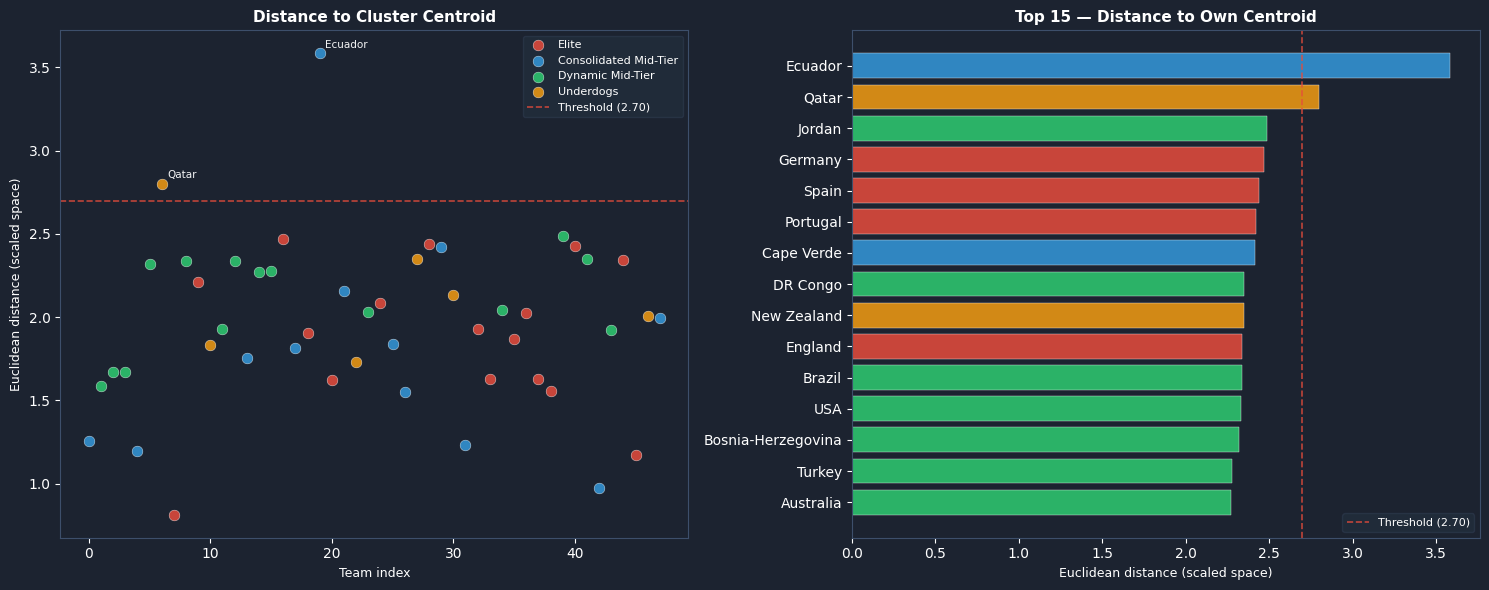

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#1C2330")

# ── Left: distance distribution with threshold line ───────────────────────────
ax = axes[0]
ax.set_facecolor("#1C2330")

for name, color in CLUSTER_COLORS_NAMED.items():
    mask = df_snapshot["cluster_name"] == name
    ax.scatter(
        df_snapshot[mask].index,
        df_snapshot[mask]["dist_to_centroid"],
        c=color, s=60, alpha=0.85,
        edgecolors="white", linewidths=0.3,
        label=name, zorder=3,
    )

ax.axhline(threshold, color="#E74C3C", linewidth=1.2,
           linestyle="--", alpha=0.8, label=f"Threshold ({threshold:.2f})")

for _, row in df_snapshot[df_snapshot["is_anomaly"]].iterrows():
    ax.annotate(
        row["team"],
        xy=(row.name, row["dist_to_centroid"]),
        xytext=(4, 4), textcoords="offset points",
        fontsize=7.5, color="white", alpha=0.95,
    )

ax.set_title("Distance to Cluster Centroid", color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("Team index", color="white", fontsize=9)
ax.set_ylabel("Euclidean distance (scaled space)", color="white", fontsize=9)
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#3D4F6B")
ax.legend(fontsize=8, labelcolor="white", facecolor="#2C3E50",
          edgecolor="#3D4F6B", framealpha=0.3)

# ── Right: top 15 teams by distance (horizontal bar) ──────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1C2330")

top15 = df_snapshot.nlargest(15, "dist_to_centroid").sort_values("dist_to_centroid")
bar_colors = [CLUSTER_COLORS_NAMED[n] for n in top15["cluster_name"]]

bars = ax2.barh(top15["team"], top15["dist_to_centroid"],
                color=bar_colors, edgecolor="white", linewidth=0.3, alpha=0.85)
ax2.axvline(threshold, color="#E74C3C", linewidth=1.2,
            linestyle="--", alpha=0.8, label=f"Threshold ({threshold:.2f})")

ax2.set_title("Top 15 — Distance to Own Centroid", color="white",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Euclidean distance (scaled space)", color="white", fontsize=9)
ax2.tick_params(colors="white")
for spine in ax2.spines.values():
    spine.set_edgecolor("#3D4F6B")
ax2.legend(fontsize=8, labelcolor="white", facecolor="#2C3E50",
           edgecolor="#3D4F6B", framealpha=0.3)

plt.tight_layout()
fig_path = FIGURES_DIR / "clustering_anomalies.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Figure saved → {fig_path}")
plt.show()

## 8. Anomaly Interpretation

Two teams exceed the distance threshold (mean + 1.5σ = 2.696):

### Ecuador — Consolidated Mid-Tier (distance: 3.585)
The most extreme outlier in the dataset. Ecuador's Elo (1982) is nearly identical
to the Elite cluster average (1983), yet it clusters in Consolidated Mid-Tier due
to severely poor recent form: 0.2 win rate and 0.6 goals scored per match over
the last 10 games. This represents a team in sharp decline arriving at the
tournament well below its historical strength.

**Implication for the model:** Ecuador's match predictions carry high uncertainty.
The Elo-based prior says competitive; the form signal says vulnerable. The supervised
model will need to resolve this tension through feature weighting — this is exactly
the kind of case where having both signals as separate features adds value over
using either alone.

### Qatar — Underdogs (distance: 2.799)
Qatar sits at the extreme negative end of the Underdogs cluster: lowest win rate
(0.1) and highest goals conceded (1.9) of the group. While correctly placed in
the weakest cluster, its profile is more extreme than its cluster peers, making
it the most exposed team in the tournament by these metrics.

### Anomaly flag as feature
The `is_anomaly` boolean and `dist_to_centroid` continuous value are both retained
in `team_snapshot_clustered.parquet` and will be available as features in the
supervised model. High `dist_to_centroid` is a proxy for prediction uncertainty
and can inform confidence intervals in the Monte Carlo simulation.